# 13_get_sequence_encodings

Run sequence encoding generation using `agentic_protein_design.steps.get_sequence_encodings`.
This notebook reflects the current step API (`root_key`, `data_subfolder`, `encodings_subfolder`).

## Python Path Setup

In [1]:
from pathlib import Path
import sys

# Section 1: Resolve repo root from either project root or notebooks/ cwd.
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd

# Section 2: Add repo and src roots to sys.path for imports.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("repo_root:", repo_root)
print("src_root:", src_root)


repo_root: /Users/charmainechia/Documents/projects/agentic-protein-design
src_root: /Users/charmainechia/Documents/projects/agentic-protein-design/src


## Imports

In [2]:
import importlib
import agentic_protein_design.steps.get_sequence_encodings as enc_step
from project_config.variables import address_dict

enc_step = importlib.reload(enc_step)

default_user_inputs = enc_step.default_user_inputs
parse_sequence_input = enc_step.parse_sequence_input
split_feature_sets = enc_step.split_feature_sets
get_sequence_encodings = enc_step.get_sequence_encodings


## User Inputs

In [3]:
user_inputs = default_user_inputs()

# Section 1: Configure output root and subfolders.
user_inputs["root_key"] = 'PIPS2' # 'ECOHARVEST' # 'MUTAGENESIS-DATA-BENCHMARKS' # "examples" # "ppk2-hmo" #
user_inputs["data_subfolder"] = 'ET096_mutagenesis' # 'RML_R1' # 'D7PM05_CLYGR_Somermeyer_2022'# "Q65J43_BACLD_g4_Thomas_2025" # "ET096_R1-2" #
user_inputs["encodings_subfolder"] = "encodings/"
filename = f'{user_inputs["data_subfolder"]}.csv' # None # "ET096_R1-2.csv" #
user_inputs["filename_prefix"] = filename.split('.')[0] + "_"  if filename is not None else ""

# Section 2: Configure sequence input source.
# Use an absolute path for notebook portability.
# user_inputs["sequence_input"] = None
data_root = (repo_root / Path(address_dict[user_inputs["root_key"]])).resolve()
user_inputs["sequence_input"] = str(
    data_root / "expdata" / user_inputs["data_subfolder"] / filename
)

# Section 3: Configure column names and optional base sequence fallback.
user_inputs["sequence_col"] = "sequence"
user_inputs["sequence_base_col"] = "sequence_base"
user_inputs["mutation_col"] = "mutations"
# user_inputs["sequence_base"] = f'sequences/{user_inputs["data_subfolder"]}.fasta' # None
# user_inputs["sequence_base"] = 'MVPIKRQSNSTVDSLPPLIPSRTSAPSSSPSTTDPEAPAMSRNGPLPSDVETKYGMALNATSYPDSVVQAMSIDGGIRAATSQEINELTYYTTLSANSYCRTVIPGATWDCIHCDATEDLKIIKTWSTLIYDTNAMVARGDSEKTIYIVFRGSSSIRNWIADLTFVPVSYPPVSGTKVHKGFLDSYGEVQNELVATVLDQFKQYPSYKVAVTGHSLGGATALLCALDLYQREEGLSSSNLFLYTQGQPRVGDPAFANYVVSTGIPYRRTVNERDIVPHLPPAAFGFLHAGEEYWITDNSPETVQVCTSDLETSDCSNSIVPFTSVLDHLSYFGINTGLCT'

# Section 4: Configure feature sets.
# Default: FEATURE_SETS_DEFAULT from project_config/feature_registry.py
# user_inputs["feature_sets"] = None
# Example explicit list:
user_inputs["feature_sets"] = [
    "one_hot",
    "georgiev",
    "esm2-650m_LLR",
    # "esm2-650m_meanPLL",
    # "esm2-650m_per_residue",
    "esm2-650m_mean_pooled",
    # "esmc-600m_LLR",
    # "esm2-650m_meanPLL",
    # "esmc-600m_per_residue",
    # "esmc-600m_mean_pooled",
    "poet2_LLR",
    # "poet2_meanPLL",
    # "poet2_per_residue",
    "poet2_mean_pooled",
    # "poet2_svd_pooled",
]

# Section 5: Optional runtime controls.
user_inputs["get_embeddings_for_seq_base"] = False
user_inputs["classical_max_length"] = None
user_inputs["marginal_type"] = 'masked' # "wt" #
user_inputs["llr_cache_vect_filename_prefix"] = 'ET096_' # 'RML-propeptide-mature_' # user_inputs["data_subfolder"]+'_' # 'ET096_' # 'ppk2_' #
user_inputs["resave_llr_cache_if_found"] = False
user_inputs["mutations_sep"] = ":"
user_inputs["layers"] = {'esm2-650m': [33], 'esmc-600m': [36], 'poet2':[12]}
user_inputs["n_components"] = 1024
user_inputs["sample_mutants_for_svd"] = False
user_inputs["svd_data_reduction"] = None
user_inputs["chunk_size"] = 3000
user_inputs["cleanup_chunk_files"] = True
user_inputs["batch_size"] = 4
user_inputs["device"] = None

user_inputs


{'root_key': 'PIPS2',
 'data_subfolder': 'ET096_mutagenesis',
 'encodings_subfolder': 'encodings/',
 'filename_prefix': 'ET096_mutagenesis_',
 'sequence_input': '/Users/charmainechia/Documents/projects/PIPS/PIPS2-UPOs-data/expdata/ET096_mutagenesis/ET096_mutagenesis.csv',
 'sequence_col': 'sequence',
 'sequence_base_col': 'sequence_base',
 'mutation_col': 'mutations',
 'sequence_base': None,
 'feature_sets': ['one_hot',
  'georgiev',
  'esm2-650m_LLR',
  'esm2-650m_mean_pooled',
  'poet2_LLR',
  'poet2_mean_pooled'],
 'get_embeddings_for_seq_base': False,
 'classical_max_length': None,
 'marginal_type': 'masked',
 'llr_cache_vect_filename_prefix': 'ET096_',
 'resave_llr_cache_if_found': False,
 'mutations_sep': ':',
 'layers': {'esm2-650m': [33], 'esmc-600m': [36], 'poet2': [12]},
 'n_components': 1024,
 'sample_mutants_for_svd': False,
 'svd_data_reduction': None,
 'chunk_size': 3000,
 'cleanup_chunk_files': True,
 'batch_size': 4,
 'device': None,
 'save_per_residue_embeddings': True

## Run Step

sequence_input: /Users/charmainechia/Documents/projects/PIPS/PIPS2-UPOs-data/expdata/ET096_mutagenesis/ET096_mutagenesis.csv
Obtaining one_hot encodings...
Obtaining georgiev encodings...
Obtaining LLR scores for esm2-650m...
[resolve_llr_cache_paths] vect cache NOT FOUND: /Users/charmainechia/Documents/projects/PIPS/PIPS2-UPOs-data/encodings/LLR/ET096_esm2-650m_LLR-masked_vect.csv
Device: cpu
[masked-marginal] Processing base sequence (len=243) with masked_batch_size=4...
[masked-marginal] 4/243 (1.6%) | 0.48 pos/s | ETA 497.0s
[masked-marginal] 8/243 (3.3%) | 0.75 pos/s | ETA 312.8s
[masked-marginal] 12/243 (4.9%) | 0.93 pos/s | ETA 247.3s
[masked-marginal] 16/243 (6.6%) | 1.06 pos/s | ETA 213.4s
[masked-marginal] 20/243 (8.2%) | 1.16 pos/s | ETA 191.4s
[masked-marginal] 24/243 (9.9%) | 1.24 pos/s | ETA 176.0s
[masked-marginal] 28/243 (11.5%) | 1.31 pos/s | ETA 164.5s
[masked-marginal] 32/243 (13.2%) | 1.36 pos/s | ETA 155.3s
[masked-marginal] 36/243 (14.8%) | 1.40 pos/s | ETA 147.9s

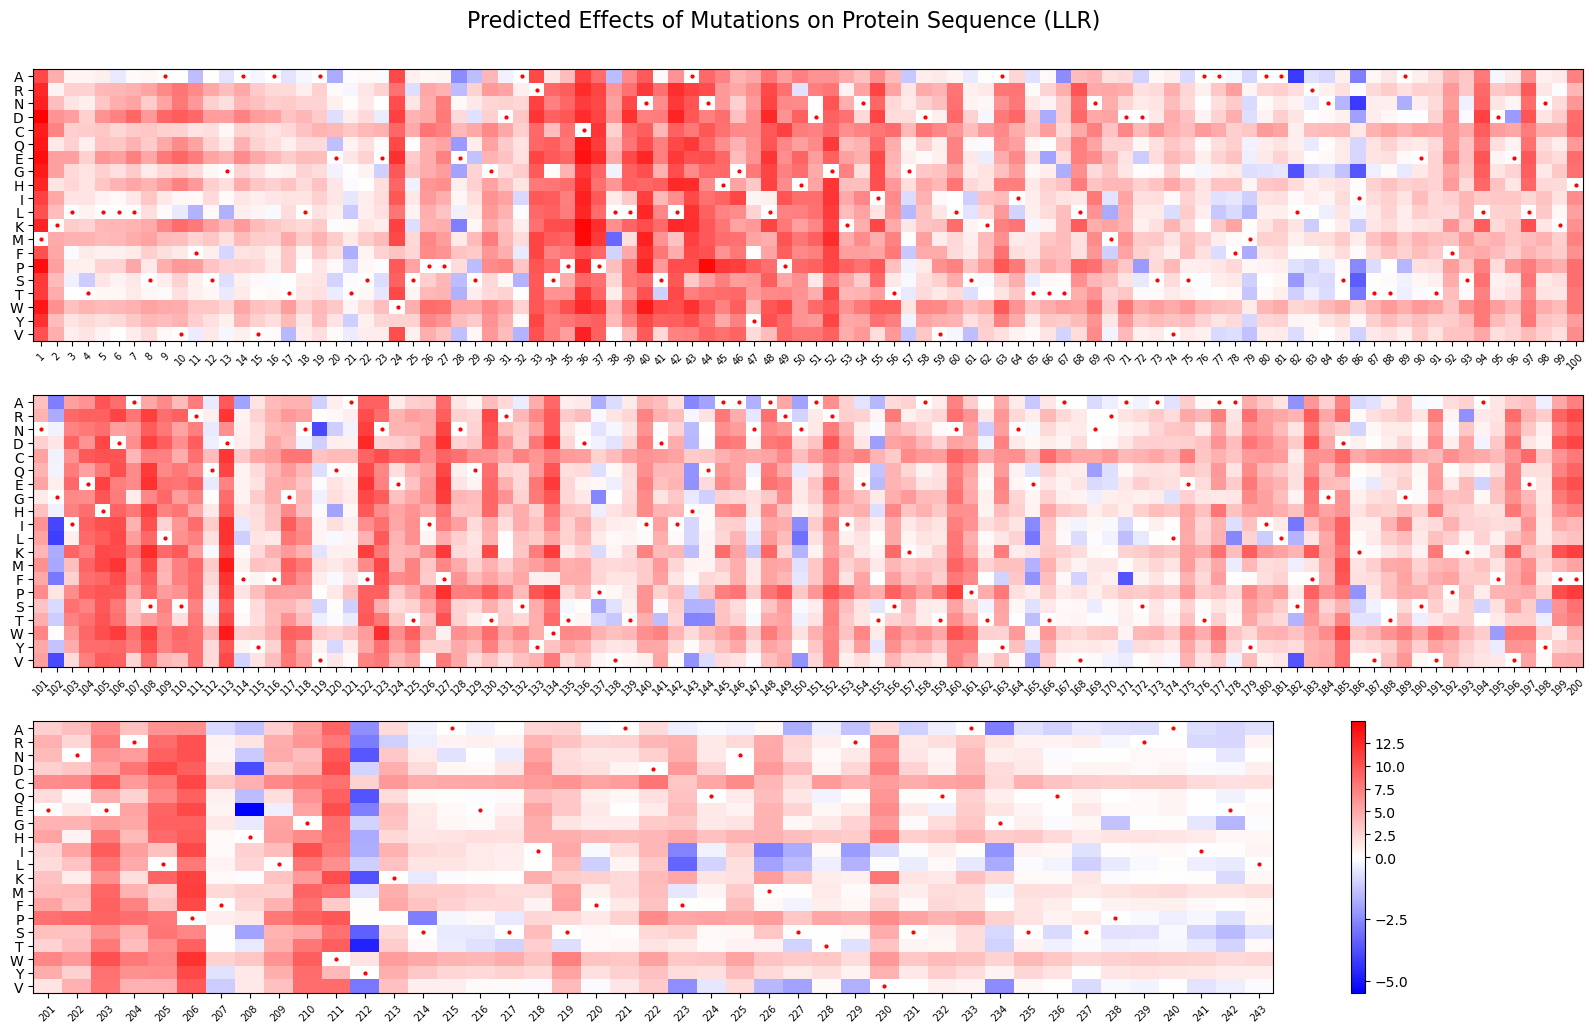

[zeroshot/masked-marginal] Saved LLR cache: /Users/charmainechia/Documents/projects/PIPS/PIPS2-UPOs-data/encodings/LLR/ET096_esm2-650m_LLR-masked_vect.csv
[zeroshot/masked-marginal] Saved raw scores: /Users/charmainechia/Documents/projects/PIPS/PIPS2-UPOs-data/encodings/ET096_mutagenesis/ET096_mutagenesis_esm2-650m_LLR-masked.csv
Obtaining embeddings for esm2-650m...
Device: cpu
[esm2 embeddings] [####################] 349/349
[get_embeddings] Saved mean_pooled layer 33: /Users/charmainechia/Documents/projects/PIPS/PIPS2-UPOs-data/encodings/ET096_mutagenesis/ET096_mutagenesis_esm2-650m_mean_pooled-33.npy (shape=(349, 1280))
Obtaining LLR scores for poet2...
[resolve_llr_cache_paths] vect cache NOT FOUND: /Users/charmainechia/Documents/projects/PIPS/PIPS2-UPOs-data/encodings/LLR/ET096_poet2_LLR_vect.csv
Prompt ID: 7dce34e0-25c9-4a6c-b60f-ab2b13cc2b36
heatmap_min: -4.812599999999975 heatmap_max: 15.242999999999995


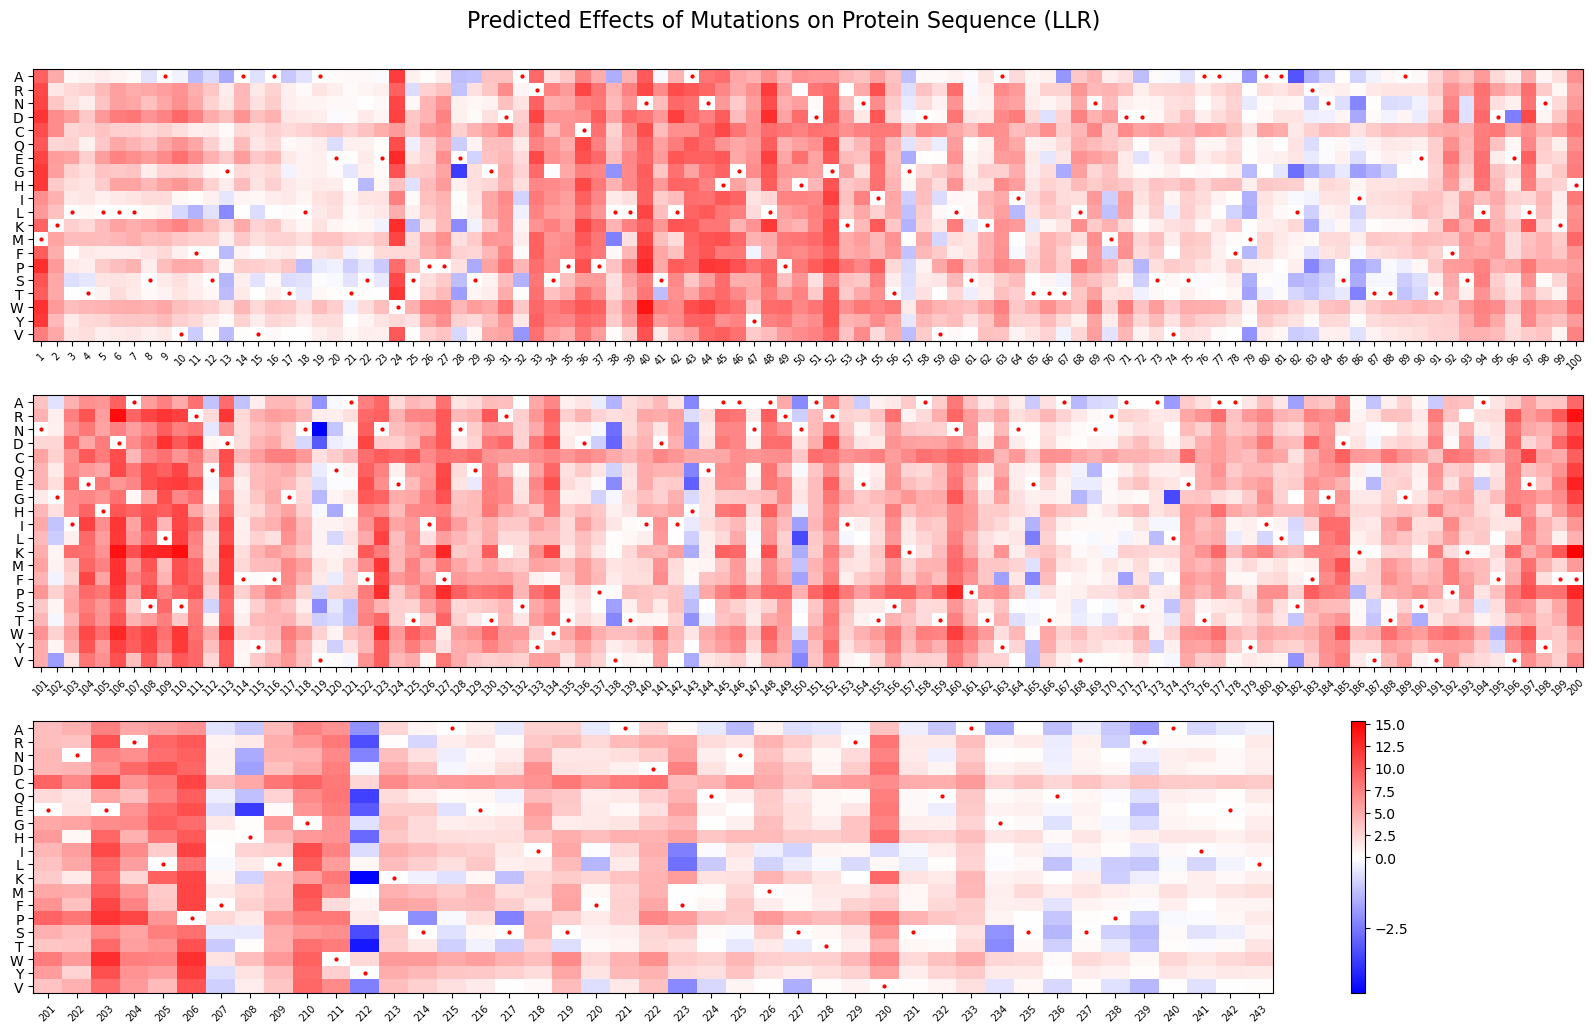

[zeroshot] Saved raw scores: /Users/charmainechia/Documents/projects/PIPS/PIPS2-UPOs-data/encodings/ET096_mutagenesis/ET096_mutagenesis_poet2_LLR.csv
Obtaining embeddings for poet2...


Waiting:   0%|          | 0/100 [00:00<?, ?it/s]Error processing line 1 of /Users/charmainechia/miniconda3/envs/agentic-protein-design/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Waiting: 100%|██████████| 100/100 [00:05<00:00, 17.79it/s, status=SUCCESS]


[get_embeddings/poet2] Saved mean_pooled layer 12: /Users/charmainechia/Documents/projects/PIPS/PIPS2-UPOs-data/encodings/ET096_mutagenesis/ET096_mutagenesis_poet2-mean_pooled-12.npy (shape=(349, 1024))
status: ok
encodings_dir: /Users/charmainechia/Documents/projects/PIPS/PIPS2-UPOs-data/encodings/ET096_mutagenesis
n_classical_features: 2
n_plm_features: 4
classical result keys: ['georgiev', 'one_hot']
plm result keys: ['esm2-650m_LLR', 'esm2-650m_mean_pooled', 'poet2_LLR', 'poet2_mean_pooled']


In [5]:
# Section 1: Execute sequence encoding workflow.
result = get_sequence_encodings(user_inputs)

# Section 2: Print concise run summary.
print("status:", result.get("status", ""))
print("encodings_dir:", result.get("encodings_dir", ""))
print("n_classical_features:", len(result.get("feature_sets", {}).get("classical", [])))
print("n_plm_features:", len(result.get("feature_sets", {}).get("plm", [])))
print("classical result keys:", sorted(result.get("classical_results", {}).keys()))
print("plm result keys:", sorted(result.get("plm_results", {}).keys()))
